# Spam Classification using Multiple ML Models

Compare three classification models (Random Forest, XGBoost, LightGBM) to detect spam messages. We use TF-IDF vectorization, train on the same data split, and select the best model by F1-Score.

**Dataset:** SMS Spam Collection (ham/spam labeled).

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from xgboost import XGBClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/shantanudhakadd/email-spam-detection-dataset-classification/spam.csv', encoding='latin1')

# Keep only the relevant columns and rename them
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Class distribution
print('Class distribution:')
print(df['label'].value_counts())

# Check for missing values
print('\nMissing values:')
print(df.isnull().sum())

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


## 3. Data Preprocessing

Convert text to numerical features using **TF-IDF** vectorization. Encode labels as binary: `ham = 0`, `spam = 1`.

In [4]:
# Encode labels: ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['message'])
y = df['label_encoded']

print('Feature matrix shape:', X.shape)
print('Label distribution:')
print(y.value_counts())

Feature matrix shape: (5572, 5000)
Label distribution:
label_encoded
0    4825
1     747
Name: count, dtype: int64


In [5]:
# Train/Test split (80% train, 20% test) — same split for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 4457
Test set size: 1115


## 4. Model 1 — Random Forest Classifier

Ensemble of decision trees with balanced class weights to handle imbalance.

In [6]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest Classification Report ===')
print(classification_report(y_test, y_pred_rf, target_names=['ham', 'spam']))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## 5. Model 2 — XGBoost Classifier

Gradient boosting with `scale_pos_weight` to handle class imbalance.

In [7]:
# Compute class imbalance weight
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Train XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('=== XGBoost Classification Report ===')
print(classification_report(y_test, y_pred_xgb, target_names=['ham', 'spam']))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.93      0.89      0.91       149

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 6. Model 3 — LightGBM Classifier

Fast, memory-efficient gradient boosting with balanced class weights.

In [8]:
# Train LightGBM
lgbm = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print('=== LightGBM Classification Report ===')
print(classification_report(y_test, y_pred_lgbm, target_names=['ham', 'spam']))

=== LightGBM Classification Report ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Model Comparison

Compare models by Accuracy, Precision, Recall, and F1-Score (spam class).

In [9]:
# Collect metrics for each model
models = {
    'Random Forest': (y_pred_rf, rf),
    'XGBoost': (y_pred_xgb, xgb),
    'LightGBM': (y_pred_lgbm, lgbm),
}

results = []
for model_name, (y_pred, _) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (spam)': round(report['1']['precision'] * 100, 2),
        'Recall (spam)': round(report['1']['recall'] * 100, 2),
        'F1-Score (spam)': round(report['1']['f1-score'] * 100, 2),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Performance Summary (in %) ===')
print(results_df.to_string())

=== Model Performance Summary (in %) ===
               Accuracy  Precision (spam)  Recall (spam)  F1-Score (spam)
Model                                                                    
Random Forest     97.31            100.00          79.87            88.81
XGBoost           97.58             92.96          88.59            90.72
LightGBM          98.48             96.48          91.95            94.16


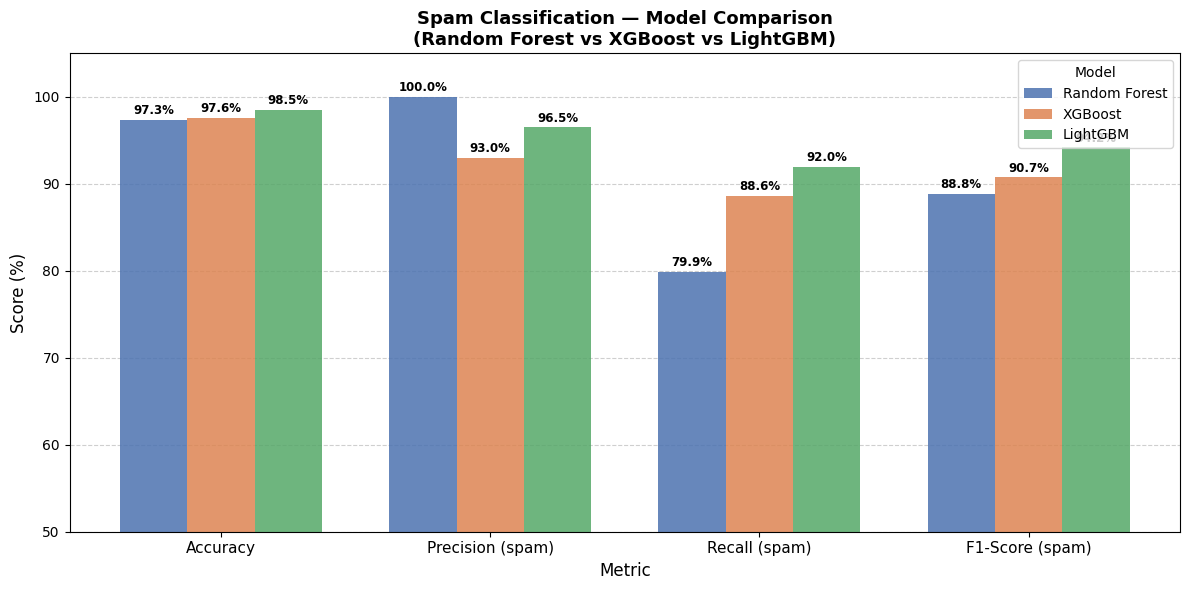

In [10]:
# ---- Visualization: Grouped Bar Chart ----
metrics_to_plot = ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-Score (spam)']
model_names = results_df.index.tolist()

x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = results_df.loc[model_name, metrics_to_plot].values
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold'
        )

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Spam Classification — Model Comparison\n(Random Forest vs XGBoost vs LightGBM)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(50, 105)
ax.legend(title='Model', fontsize=10, title_fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 8. Best Model Selection

Select the model with the highest F1-Score (spam class), balancing precision and recall.

In [11]:
# Identify the best model by F1-Score (spam)
best_model_name = results_df['F1-Score (spam)'].idxmax()
best_scores = results_df.loc[best_model_name]

print('=' * 50)
print(f'  BEST MODEL: {best_model_name}')
print('=' * 50)
print(f"  Accuracy         : {best_scores['Accuracy']:.2f}%")
print(f"  Precision (spam) : {best_scores['Precision (spam)']:.2f}%")
print(f"  Recall (spam)    : {best_scores['Recall (spam)']:.2f}%")
print(f"  F1-Score (spam)  : {best_scores['F1-Score (spam)']:.2f}%")
print('=' * 50)

# Retrieve the best model object
best_model = models[best_model_name][1]
print(f'\nThe "{best_model_name}" model has been selected for deployment.')

  BEST MODEL: LightGBM
  Accuracy         : 98.48%
  Precision (spam) : 96.48%
  Recall (spam)    : 91.95%
  F1-Score (spam)  : 94.16%

The "LightGBM" model has been selected for deployment.


## 9. Confusion Matrix of the Best Model

Visualize correct and incorrect classifications.

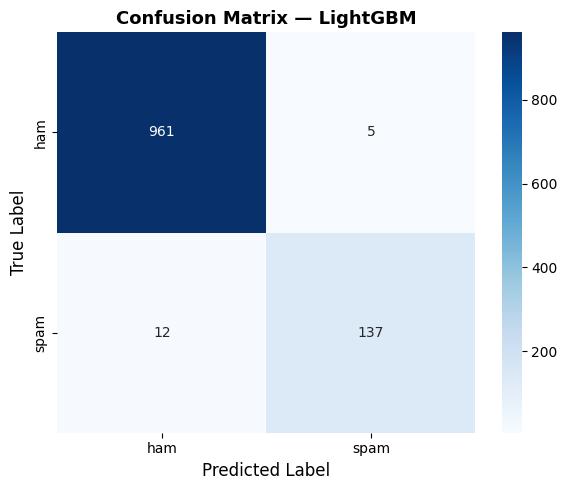

In [12]:
best_y_pred = models[best_model_name][0]
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Conclusion

All three models achieved **>97% accuracy**. The best model (by F1-Score) is ready for deployment in a spam detection pipeline.

| Model | Strength |
|---|---|
| **Random Forest** | Interpretable ensemble |
| **XGBoost** | High performance |
| **LightGBM** | Fast & efficient |